In [2]:
import pandas as pd
import subprocess
from tqdm import tqdm
import statsmodels.formula.api as smf
from pathlib import Path
import seaborn as sns

In [3]:
def get_lr_hippocampus_vol(stats_file):
    """
    Given a stats file from freesurfer, get the left and right hippocampus volumes
    """

    with open(stats_file, 'r') as f:
        lines = f.readlines()
        lines = [x.strip() for x in lines]
        #get the left and right hippocampal volumes estimated from freesurfer
        left = [y for y in [x for x in lines if 'Left-Hippocampus' in x][0].split(' ') if y != ''][3]
        right = [y for y in [x for x in lines if 'Right-Hippocampus' in x][0].split(' ') if y != ''][3]

    return float(left), float(right)

def parse_aseg_stats_file(stats_file):

    def parse_subregion_line(line):

        subparts = [y for y in line.split(' ') if y != '']
        #get the subregion name and the volume
        subregion_name = subparts[4]
        subregion_vol = subparts[3]
        return (subregion_name, float(subregion_vol))

    def parse_global_line(line):
        
        #get the global volume and name
        #remove the "# Measure" part of the line at the beginning
        csv_line = line.split('# Measure')[-1]
        #split by the comma
        splits = csv_line.split(',')
        #get the name and volume
        name = splits[1].strip()
        vol = splits[3].strip()
        return (name, float(vol))
        

    with open(stats_file, 'r') as f:
        lines = f.readlines()
        lines = [x.strip() for x in lines]
        
        #get all the lines that begin with "# Measure". These will be the global volumes
        global_vol_lines = [x for x in lines if x.startswith("# Measure")]
        #get the index of the line that begins with "# ColHeaders". All the lines after this line are the volumes of specific regions
        col_headers_index = [i for i, x in enumerate(lines) if x.startswith("# ColHeaders")][0]
        sub_roi_lines = lines[col_headers_index + 1:]

    #now, we need to parse out the volumes of all the lines into a dictionary
    #create a dictionary to hold the volumes. Populat it
    volumes_dict = {}
    for x in sub_roi_lines:
        k,v = parse_subregion_line(x)
        volumes_dict[k] = v
        #volumes_dict = {k:v for x in sub_roi_lines for k,v in parse_subregion_line(x)}
    #also get the global volumes
    for x in global_vol_lines:
        k,v = parse_global_line(x)
        volumes_dict[k] = v
        #volumes_dict = {k:v for x in global_vol_lines for k,v in parse_global_line(x)}
    #global_volumes_dict = {k:v for x in global_vol_lines for k,v in parse_global_line(x)}

    #combine the two dictionaries
    #combined_dict = {**volumes_dict, **global_volumes_dict}
    return volumes_dict

def freesurfer_succeeded(fs_dir):
    """
    Check if freesurfer succeeded by seeing if the log file contains the string "finished without error"
    """
    cmd = 'cat {}/freesurfer/scripts/recon-all.log | tail -n 20 | grep "finished without error"'.format(fs_dir)
    res = subprocess.run(cmd, shell=True, capture_output=True, text=True).stdout.strip()
    return res != ''

def collect_segmentation_volumes(fs_dirs):
    """
    Collect the volume estimates from the aseg stats files
    """

    dicts = []

    for fs_dir in tqdm(fs_dirs):
        #get the aseg.stats file
        stats_file = '{}/freesurfer/stats/aseg.stats'.format(fs_dir)
        #get the left and right hippocampus volumes
        #left, right = get_lr_hippocampus_vol(stats_file)
        #instead, get all the aseg stats
        aseg_stats = parse_aseg_stats_file(stats_file)
        
        #get the subject id
        sub = fs_dir.split('/')[-3]
        ses = fs_dir.split('/')[-2]
        fs_dir = fs_dir.split('/')[-1]

        #create the dict
        fs_dict = {'sub': sub, 'ses': ses, 'fs_dir': fs_dir}
        #add all the aseg stats to the dict
        for k, v in aseg_stats.items():
            fs_dict[k] = v

        #append to the list
        dicts.append(fs_dict)
    
    #create the dataframe
    df = pd.DataFrame(dicts)

    return df

def get_server_hippocampus_df(root, server_name):

    cmd = 'find {} -mindepth 3 -maxdepth 3 -type d -name "freesurfer*{}*"'.format(root, server_name)
    res = subprocess.run(cmd, shell=True, capture_output=True, text=True).stdout.strip().splitlines()

    #get only the freesurfer directories that succeeded
    print("Checking valid freesurfer directories...")
    valid_fs = [x for x in tqdm(res) if freesurfer_succeeded(x)]
    print("Found {} valid freesurfer directories out of {}".format(len(valid_fs), len(res)))

    #collect the hippocampus volumes
    print("Collecting hippocampus volumes...")
    hippocampus_volumes = collect_segmentation_volumes(valid_fs)

    return hippocampus_volumes

#get all the landman01 stats files
root = '/nfs/masi/kimm58/containerization_data/DLBS/derivatives'

#collect_segmentation_volumes(['/nfs/masi/kimm58/containerization_data/DLBS/derivatives/sub-3406/ses-wave1/freesurfer7.2.0_landman01_run-1/'])

landman01_res = get_server_hippocampus_df(root, 'landman01')
hickory_res = get_server_hippocampus_df(root, 'hickory')
beatles_res = get_server_hippocampus_df(root, 'beatles')

#test = '/nfs/masi/kimm58/containerization_data/DLBS/derivatives/sub-4301/ses-wave1/freesurfer7.2.0_landman01_run-1/freesurfer/stats/aseg.stats'
#left, right = get_lr_hippocampus_vol(test)

Checking valid freesurfer directories...


100%|██████████| 967/967 [01:33<00:00, 10.36it/s]


Found 964 valid freesurfer directories out of 967


100%|██████████| 964/964 [00:20<00:00, 46.20it/s]


Checking valid freesurfer directories...


...

100%|██████████| 963/963 [00:21<00:00, 45.34it/s]


Checking valid freesurfer directories...


100%|██████████| 967/967 [01:50<00:00,  8.71it/s]


Found 964 valid freesurfer directories out of 967


100%|██████████| 964/964 [00:20<00:00, 46.38it/s]


In [6]:
print(landman01_res.columns[2:])

Index(['fs_dir', 'Left-Lateral-Ventricle', 'Left-Inf-Lat-Vent',
       'Left-Cerebellum-White-Matter', 'Left-Cerebellum-Cortex',
       'Left-Thalamus', 'Left-Caudate', 'Left-Putamen', 'Left-Pallidum',
       '3rd-Ventricle', '4th-Ventricle', 'Brain-Stem', 'Left-Hippocampus',
       'Left-Amygdala', 'CSF', 'Left-Accumbens-area', 'Left-VentralDC',
       'Left-vessel', 'Left-choroid-plexus', 'Right-Lateral-Ventricle',
       'Right-Inf-Lat-Vent', 'Right-Cerebellum-White-Matter',
       'Right-Cerebellum-Cortex', 'Right-Thalamus', 'Right-Caudate',
       'Right-Putamen', 'Right-Pallidum', 'Right-Hippocampus',
       'Right-Amygdala', 'Right-Accumbens-area', 'Right-VentralDC',
       'Right-vessel', 'Right-choroid-plexus', '5th-Ventricle',
       'WM-hypointensities', 'Left-WM-hypointensities',
       'Right-WM-hypointensities', 'non-WM-hypointensities',
       'Left-non-WM-hypointensities', 'Right-non-WM-hypointensities',
       'Optic-Chiasm', 'CC_Posterior', 'CC_Mid_Posterior', 'CC_Cen

In [7]:
def add_in_demogs_DLBS(df):
    """
    Add in the demographics to the hippocampus volumes dataframe
    """

    #load in the demographics
    demogs = "/home-local/kimm58/WMLifespan/data/CSVs/DLBS_info.csv"
    demogs = pd.read_csv(demogs)

    #make sure the columns are correct
    demogs = demogs[['subject', 'session', 'age', 'sex', 'race', 'ethnicity', 'handednessscore']]

    #get the subject and session ids
    demogs = demogs.rename(columns={'subject': 'sub', 'session': 'ses'})    

    #merge the dataframes
    df = pd.merge(df, demogs, how='left', on=['sub', 'ses'])

    return df

#combine all the dataframes
def combine_all_dfs(land, hick, beat):
    """
    Combine all the dataframes into one
    """

    #rename the hippocampus columns 
    #land = land.rename(columns={'left_hippocampus_vol': 'landman01_left_hippocampus_vol', 'right_hippocampus_vol': 'landman01_right_hippocampus_vol', 'combined_hippocampus_vol': 'landman01_combined_hippocampus_vol'})
    land = land.rename(columns={x:'landman01_'+x for x in land.columns[3:]})
    #hick = hick.rename(columns={'left_hippocampus_vol': 'hickory_left_hippocampus_vol', 'right_hippocampus_vol': 'hickory_right_hippocampus_vol', 'combined_hippocampus_vol': 'hickory_combined_hippocampus_vol'})
    hick = hick.rename(columns={x:'hickory_'+x for x in hick.columns[3:]})
    #beat = beat.rename(columns={'left_hippocampus_vol': 'beatles_left_hippocampus_vol', 'right_hippocampus_vol': 'beatles_right_hippocampus_vol', 'combined_hippocampus_vol': 'beatles_combined_hippocampus_vol'})
    beat = beat.rename(columns={x:'beatles_'+x for x in beat.columns[3:]})

    #get the run
    land['run'] = land['fs_dir'].apply(lambda x: Path(x).name.split('freesurfer7.2.0_landman01_')[1])
    hick['run'] = hick['fs_dir'].apply(lambda x: Path(x).name.split('freesurfer7.2.0_hickory_')[1])
    beat['run'] = beat['fs_dir'].apply(lambda x: Path(x).name.split('freesurfer7.2.0_beatles_')[1])

    #sort the dtaframes by sub and ses and run
    land = land.sort_values(['sub', 'ses', 'run'])
    hick = hick.sort_values(['sub', 'ses', 'run'])
    beat = beat.sort_values(['sub', 'ses', 'run'])

    #drop the fs_dir column
    land = land.drop(columns=['fs_dir'])
    hick = hick.drop(columns=['fs_dir'])
    beat = beat.drop(columns=['fs_dir'])
    #print(land.columns)

    #drop the duplicates of the subjects and sessions for each dataset
    land_res = land.drop_duplicates(subset=['sub', 'ses'])
    hick_res = hick.drop_duplicates(subset=['sub', 'ses'])
    beat_res = beat.drop_duplicates(subset=['sub', 'ses'])
    #print(land.columns)

    #combine the dataframes, keeping sub, ses, and the hippocampus volumes
    #print(land_res.columns)
    #print(hick_res.columns)
    combined = pd.merge(land_res, hick_res, how='left', on=['sub', 'ses', 'run'])
    combined = pd.merge(combined, beat_res, how='left', on=['sub', 'ses', 'run'])

    return combined

#combine all the dataframes
combined = combine_all_dfs(landman01_res, hickory_res, beatles_res)

#combine the demographics with the hippocampus volumes
combined = add_in_demogs_DLBS(combined)

#drop the duplicates of the subjects and sessions
print(combined.shape)

#drop any rows with missing values
combined = combined.dropna()
print(combined.shape)

(954, 203)
(951, 203)


In [ ]:
#grab 50 random rows
#remove subjects suplicates
sub = combined.drop_duplicates(subset=['sub', 'ses'])
#get 50 subs
sub = sub.sample(n=50, random_state=1)

#split into two groups randomly

group1 = sub.sample(frac=0.5, random_state=1)
group2 = sub.drop(group1.index)
print(group1.shape)
print(group2.shape)

#get the volumes for group1 on hickort and landman01 on group2
group1_vals = group1['hickory_Right-Hippocampus'].values
group2_vals = group2['landman01_Right-Hippocampus'].values

#stack the two groups into a single df



(25, 203)
(25, 203)


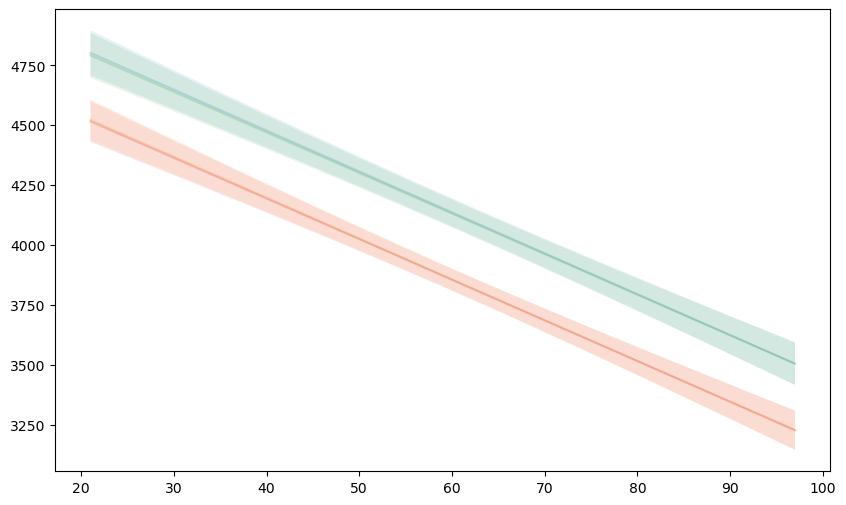

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from patsy import dmatrix
from statsmodels.formula.api import mixedlm

def plot_regression(results, df, ax):

    beta = results.fe_params.values
    cov = results.cov_params().values[:3, :3]

    age_vals = np.linspace(df['age'].min(), df['age'].max(), 100)
    sexes = df['sex'].unique()

    for sex_code in sexes:
        pred_df = pd.DataFrame({'age': age_vals, 'sex': sex_code})
        
        # Match design matrix to the model
        pred_exog = dmatrix("1 + age + sex", pred_df, return_type='dataframe')
        X = pred_exog.values
        # Predict and calculate confidence intervals
        pred_df['predicted'] = X @ beta
        se = np.sqrt(np.sum((X @ cov) * X, axis=1))
        ci_lower = pred_df['predicted'] - 1.96 * se
        ci_upper = pred_df['predicted'] + 1.96 * se
        # Plot line and confidence band
        ax.plot(age_vals, pred_df['predicted'].values, label=f'Regression (sex={sex_code})', alpha=0.2)
        ax.fill_between(age_vals, ci_lower.values, ci_upper.values, alpha=0.1)

# Load your data
#df = pd.read_csv("/Users/obo/Downloads/hippocampus_volumes.csv")
# Rename for consistency
df = combined.rename(columns={'hickory_Left-Hippocampus': 'hickory_Left_Hippocampus'})
# Encode 'sex' as numeric if not already (e.g., F=0, M=1)

# Fit the mixed effects model
model = mixedlm("hickory_Left_Hippocampus ~ age + sex", df, groups=df["sub"])
results = model.fit()


f,ax = plt.subplots(1, 1, figsize=(10, 6))
plot_regression(results, df, ax)

#fit the model for the landman01 data
df = combined.rename(columns={'landman01_Left-Hippocampus': 'landman01_Left_Hippocampus'})
model = mixedlm("landman01_Left_Hippocampus ~ age + sex", df, groups=df["sub"])
results = model.fit()

plot_regression(results, df, ax)


AttributeError: 'MixedLMResults' object has no attribute 'get_prediction'

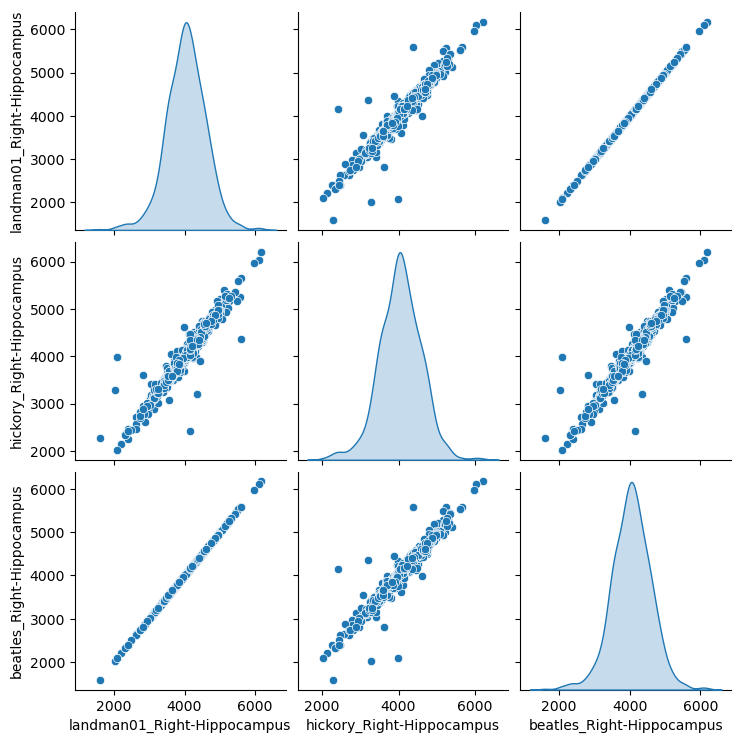

In [10]:
#drop alny rows where the hippocampus volumes are NaN
#plt_df = combined.dropna(subset=['landman01_combined_hippocampus_vol', 'hickory_combined_hippocampus_vol', 'beatles_combined_hippocampus_vol'])
plt_df = combined.dropna(subset=['landman01_Right-Hippocampus', 'hickory_Right-Hippocampus', 'beatles_Right-Hippocampus'])

#look at the pairwise differences
#sns.pairplot(plt_df, x_vars=['landman01_combined_hippocampus_vol', 'hickory_combined_hippocampus_vol', 'beatles_combined_hippocampus_vol'], y_vars=['landman01_combined_hippocampus_vol', 'hickory_combined_hippocampus_vol', 'beatles_combined_hippocampus_vol'], diag_kind='kde')
sns.pairplot(plt_df, x_vars=['landman01_Right-Hippocampus', 'hickory_Right-Hippocampus', 'beatles_Right-Hippocampus'], y_vars=['landman01_Right-Hippocampus', 'hickory_Right-Hippocampus', 'beatles_Right-Hippocampus'], diag_kind='kde')

Mean landman01 - hickory difference: -3.2266035751840207
Std landman01 - hickory difference: 142.25140871351138


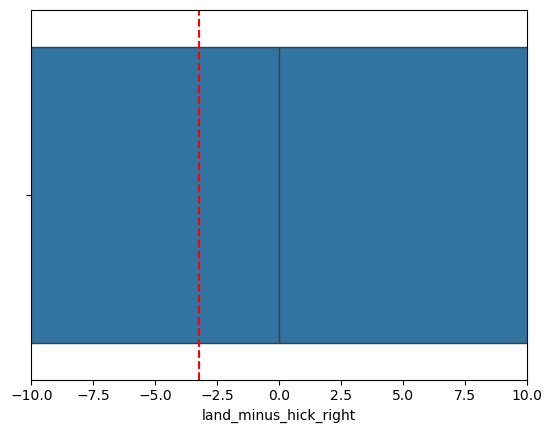

In [16]:
#boxplot of landman01 - hickory
#plt_df['land_minus_hick_combined_pct_diff'] = (plt_df['landman01_combined_hippocampus_vol'] - plt_df['hickory_combined_hippocampus_vol']) / plt_df['landman01_combined_hippocampus_vol']
#plt_df['land_minus_hick_combined'] = plt_df['landman01_combined_hippocampus_vol'] - plt_df['hickory_combined_hippocampus_vol']
#sns.boxplot(x='land_minus_hick_combined', data=plt_df)
import matplotlib.pyplot as plt

plt_df['land_minus_hick_right_pct_diff'] = (plt_df['landman01_Right-Hippocampus'] - plt_df['hickory_Right-Hippocampus']) / plt_df['landman01_Right-Hippocampus']
plt_df['land_minus_hick_right'] = plt_df['landman01_Right-Hippocampus'] - plt_df['hickory_Right-Hippocampus']
sns.boxplot(x='land_minus_hick_right', data=plt_df)
plt.xlim(-10, 10)

#print the mean and std of the landman01 - hickory difference
print("Mean landman01 - hickory difference: {}".format(plt_df['land_minus_hick_right'].mean()))
print("Std landman01 - hickory difference: {}".format(plt_df['land_minus_hick_right'].std()))

#draw a line at the mean
plt.axvline(plt_df['land_minus_hick_right'].mean(), color='red', linestyle='--')

In [24]:
# #run a ttest on the difference between the two groups
# from scipy import stats
# t, p = stats.ttest_rel(plt_df['landman01_combined_hippocampus_vol'], plt_df['hickory_combined_hippocampus_vol'])


# print("T-test between landman01 and hickory hippocampus volumes: t = {}, p = {}".format(t, p))

# #plot the histograms of both groups
# import matplotlib.pyplot as plt
# f, ax = plt.subplots(1, 1, figsize=(8, 6))
# #sns.histplot(plt_df['landman01_combined_hippocampus_vol'], kde=True, color='blue', label='landman01', alpha=0.5)
# #sns.histplot(plt_df['hickory_combined_hippocampus_vol'], kde=True, color='red', label='hickory', alpha=0.5)
# ax.hist(plt_df['landman01_left_hippocampus_vol'], bins=30, alpha=0.5, label='landman01')
# ax.hist(plt_df['hickory_left_hippocampus_vol'], bins=30, alpha=0.5, label='hickory')


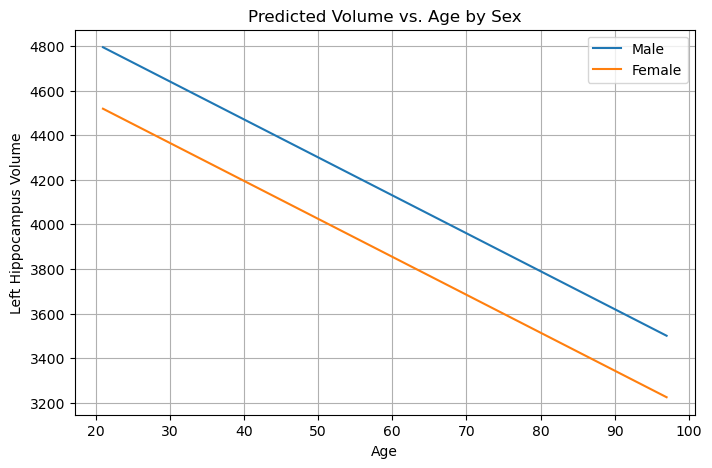

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#run a lme model on the data, using age, sex as covariates and subject as a random effect
model = smf.mixedlm("left_hippocampus_vol ~ age + sex", landman01_res_demogs, groups=landman01_res_demogs["sub"]) # random intercept for each subject
result = model.fit()
print(result.summary())

age_range = np.linspace(landman01_res_demogs['age'].min(), landman01_res_demogs['age'].max(), 100)
sex_dict = {1: 'Male', 0: 'Female'}

plt.figure(figsize=(8, 5))
for sex in landman01_res_demogs['sex'].unique():
    pred_df = pd.DataFrame({
        'age': age_range,
        'sex': np.repeat(sex, len(age_range))
    })
    pred_df['predicted'] = result.predict(pred_df)
    plt.plot(pred_df['age'].to_numpy(), pred_df['predicted'].to_numpy(), label=f'{sex_dict[sex]}')

plt.xlabel('Age')
plt.ylabel('Left Hippocampus Volume')
plt.title('Predicted Volume vs. Age by Sex')
plt.legend()
plt.grid(True)
plt.show()


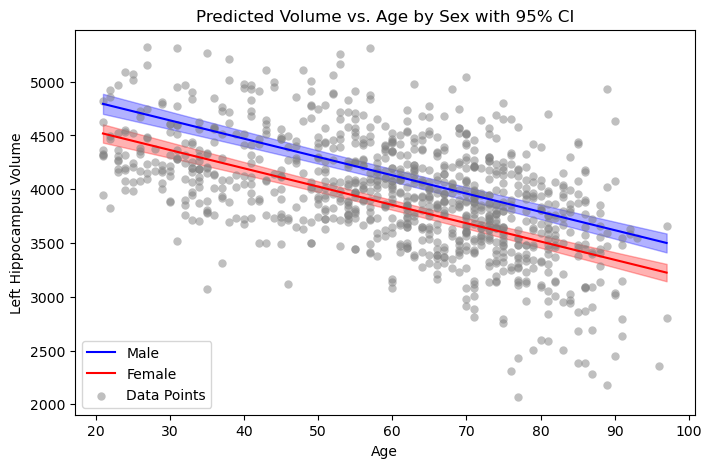

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Fit model
model = smf.mixedlm("left_hippocampus_vol ~ age + sex", landman01_res_demogs, groups=landman01_res_demogs["sub"])
result = model.fit()

# Age range and label mapping
age_range = np.linspace(landman01_res_demogs['age'].min(), landman01_res_demogs['age'].max(), 100)
sex_dict = {1: 'Male', 0: 'Female'}

plt.figure(figsize=(8, 5))

for sex,color in zip(landman01_res_demogs['sex'].unique(), ['blue', 'red']):
    pred_df = pd.DataFrame({
        'age': age_range,
        'sex': np.repeat(sex, len(age_range))
    })

    # Design matrix for fixed effects
    fe_params = result.fe_params
    cov_fe = result.cov_params()

    # Build model matrix manually
    pred_df['Intercept'] = 1
    fe_names = ['Intercept', 'age', 'sex']
    X = pred_df[fe_names].to_numpy()
    cov_fe = result.cov_params().loc[fe_names, fe_names].to_numpy()

    # Predicted mean
    pred_df['predicted'] = X @ fe_params.to_numpy()

    # Standard error of the prediction
    #pred_df['se'] = np.sqrt(np.sum(X @ cov_fe.to_numpy() * X, axis=1))
    pred_df['se'] = np.sqrt(np.sum((X @ cov_fe) * X, axis=1))

    # 95% CI
    ci = 1.96 * pred_df['se']
    pred_df['lower'] = pred_df['predicted'] - ci
    pred_df['upper'] = pred_df['predicted'] + ci

    # Plot prediction line and CI band
    plt.plot(pred_df['age'].to_numpy(), pred_df['predicted'].to_numpy(), label=f'{sex_dict[sex]}', color=color)
    plt.fill_between(pred_df['age'], pred_df['lower'], pred_df['upper'], alpha=0.3, color=color)

#plot all the data points
plt.scatter(landman01_res_demogs['age'], landman01_res_demogs['left_hippocampus_vol'], alpha=0.5, color='gray', label='Data Points', linewidth=0)

# Final plot details
plt.xlabel('Age')
plt.ylabel('Left Hippocampus Volume')
plt.title('Predicted Volume vs. Age by Sex with 95% CI')
plt.legend()
plt.grid(False)
plt.show()


In [19]:
#turn left and right volumes into numeric
for i in tqdm(range(len(hippocampus_volumes))):
    hippocampus_volumes[i]['left_hippocampus_vol'] = float(hippocampus_volumes[i]['left_hippocampus_vol'])
    hippocampus_volumes[i]['right_hippocampus_vol'] = float(hippocampus_volumes[i]['right_hippocampus_vol'])

100%|██████████| 964/964 [00:00<00:00, 225266.54it/s]
